## Data Quality Assessment Overview

In this section, we evaluate the overall quality of the dataset before proceeding to analytical tasks. We begin by normalizing the nested JSON structure into a tabular format suitable for analysis, ensuring that all attributes are accessible at the column level.

We then assess key data quality dimensions, including completeness (missing values), structural consistency, duplication, and data type validity. These checks allow us to identify potential governance gaps, inconsistencies in data collection, and fields that may require cleaning or contextual interpretation before further analysis.

### Data Quality Checklist

The dataset is assessed across the following data quality dimensions:

1. **Completeness** – Evaluation of missing or incomplete records.
2. **Uniqueness** – Detection of duplicate records and duplicate unique identifiers (_id).
3. **Consistency** – Assessment of categorical coding consistency and cross-field logical integrity.
4. **Validity** – Verification of acceptable ranges, formats, and allowed values.
5. **Accuracy (Plausibility)** – Identification of implausible but not necessarily invalid values.

Each identified issue will be quantified (count and percentage) and, where appropriate, remediation steps will be demonstrated in code.

In [158]:
import re,json
import pandas as pd
from pathlib import Path
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

In [130]:
path = Path("..") / "Data" / "raw_credit_applications.json"

with open(path, "r", encoding="utf-8") as f:
    data = json.load(f)

df = pd.DataFrame(data)
df.head()

,_id,applicant_info,financials,spending_behavior,decision,processing_timestamp,loan_purpose,notes
0,app_200,"{'full_name': 'Jerry Smith', 'email': 'jerry.s...","{'annual_income': 73000, 'credit_history_month...","[{'category': 'Shopping', 'amount': 480}, {'ca...","{'loan_approved': False, 'rejection_reason': '...",2024-01-15T00:00:00Z,NaN,NaN
1,app_037,"{'full_name': 'Brandon Walker', 'email': 'bran...","{'annual_income': 78000, 'credit_history_month...","[{'category': 'Rent', 'amount': 608}, {'catego...","{'loan_approved': False, 'rejection_reason': '...",NaN,NaN,NaN
2,app_215,"{'full_name': 'Scott Moore', 'email': 'scott.m...","{'annual_income': 61000, 'credit_history_month...","[{'category': 'Rent', 'amount': 109}]","{'loan_approved': True, 'interest_rate': 3.7, ...",NaN,vacation,NaN
3,app_024,"{'full_name': 'Thomas Lee', 'email': 'thomas.l...","{'annual_income': 103000, 'credit_history_mont...","[{'category': 'Fitness', 'amount': 575}]","{'loan_approved': True, 'interest_rate': 4.3, ...",NaN,NaN,NaN
4,app_184,"{'full_name': 'Brian Rodriguez', 'email': 'bri...","{'annual_income': 57000, 'credit_history_month...","[{'category': 'Entertainment', 'amount': 463}]","{'loan_approved': False, 'rejection_reason': '...",2024-01-15T00:00:00Z,NaN,NaN


The raw JSON dataset was successfully loaded and converted into a Pandas DataFrame. The structure confirms the presence of nested fields (e.g., applicant information, financial data, and decision details), which will require normalization before performing data quality analysis.

In [131]:
df.columns

Index(['_id', 'applicant_info', 'financials', 'spending_behavior', 'decision',
       'processing_timestamp', 'loan_purpose', 'notes'],
      dtype='object')

In [132]:
flat_raw = pd.json_normalize(data, sep=".")
flat = flat_raw.copy()
flat.head()

,_id,spending_behavior,processing_timestamp,applicant_info.full_name,applicant_info.email,applicant_info.ssn,applicant_info.ip_address,applicant_info.gender,applicant_info.date_of_birth,applicant_info.zip_code,...,financials.credit_history_months,financials.debt_to_income,financials.savings_balance,decision.loan_approved,decision.rejection_reason,loan_purpose,decision.interest_rate,decision.approved_amount,financials.annual_salary,notes
0,app_200,"[{'category': 'Shopping', 'amount': 480}, {'ca...",2024-01-15T00:00:00Z,Jerry Smith,jerry.smith17@hotmail.com,596-64-4340,192.168.48.155,Male,2001-03-09,10036,...,23,0.20,31212,False,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN
1,app_037,"[{'category': 'Rent', 'amount': 608}, {'catego...",NaN,Brandon Walker,brandon.walker2@yahoo.com,425-69-4784,10.1.102.112,M,1992-03-31,10032,...,51,0.18,17915,False,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN
2,app_215,"[{'category': 'Rent', 'amount': 109}]",NaN,Scott Moore,scott.moore94@mail.com,370-78-5178,10.240.193.250,Male,1989-10-24,10075,...,41,0.21,37909,True,NaN,vacation,3.7,59000.0,NaN,NaN
3,app_024,"[{'category': 'Fitness', 'amount': 575}]",NaN,Thomas Lee,thomas.lee6@protonmail.com,194-35-1833,192.168.175.67,Male,1983-04-25,10077,...,70,0.35,0,True,NaN,NaN,4.3,34000.0,NaN,NaN
4,app_184,"[{'category': 'Entertainment', 'amount': 463}]",2024-01-15T00:00:00Z,Brian Rodriguez,brian.rodriguez86@aol.com,480-41-2475,172.29.125.105,M,1999-05-21,10080,...,14,0.23,31763,False,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN


In [133]:
flat["spending_behavior"].head()

0    [{'category': 'Shopping', 'amount': 480}, {'ca...
1    [{'category': 'Rent', 'amount': 608}, {'catego...
2                [{'category': 'Rent', 'amount': 109}]
3             [{'category': 'Fitness', 'amount': 575}]
4       [{'category': 'Entertainment', 'amount': 463}]
Name: spending_behavior, dtype: object

In [134]:
# Total rows
n_rows = flat.shape[0]

# Build missing summary table
missing_summary = pd.DataFrame({
    "values_present": flat.notna().sum(),
    "values_missing": flat.isna().sum(),
})

missing_summary["percent_missing"] = (
    missing_summary["values_missing"] / n_rows * 100
).round(2)

# Sort by most missing
missing_summary = missing_summary.sort_values(
    by="percent_missing", ascending=False
)

missing_summary

,values_present,values_missing,percent_missing
notes,2,500,99.60
financials.annual_salary,5,497,99.00
loan_purpose,50,452,90.04
processing_timestamp,62,440,87.65
decision.rejection_reason,210,292,58.17
decision.approved_amount,292,210,41.83
decision.interest_rate,292,210,41.83
financials.annual_income,497,5,1.00
applicant_info.ip_address,497,5,1.00
applicant_info.ssn,497,5,1.00


### Missing Values Analysis

The dataset contains 502 records and 21 variables. The missingness analysis reveals substantial gaps in several fields, particularly `notes` (99.6% missing), `financials.annual_salary` (99.0% missing), `loan_purpose` (90.0% missing), and `processing_timestamp` (87.6% missing). These fields appear either optional, inconsistently recorded, or poorly governed within the data collection process.

Decision-related variables such as `decision.rejection_reason` (58.2% missing) and `decision.approved_amount` / `decision.interest_rate` (41.8% missing) likely reflect structural missingness (e.g., rejection reason only exists for rejected loans). In contrast, core financial and applicant identification fields (e.g., income, SSN, email, credit history, debt-to-income ratio) show near-complete coverage, indicating stronger governance and validation controls for critical underwriting variables.

In [135]:
flat.dtypes

_id                                  object
spending_behavior                    object
processing_timestamp                 object
applicant_info.full_name             object
applicant_info.email                 object
applicant_info.ssn                   object
applicant_info.ip_address            object
applicant_info.gender                object
applicant_info.date_of_birth         object
applicant_info.zip_code              object
financials.annual_income             object
financials.credit_history_months      int64
financials.debt_to_income           float64
financials.savings_balance            int64
decision.loan_approved                 bool
decision.rejection_reason            object
loan_purpose                         object
decision.interest_rate              float64
decision.approved_amount            float64
financials.annual_salary            float64
notes                                object
dtype: object

In [156]:
# --- Quick coercions (types) ---
# datetimes
for c in ["processing_timestamp", "applicant_info.date_of_birth"]:
    if c in flat.columns:
        flat[c] = pd.to_datetime(flat[c], errors="coerce")

# numerics (coerce strings -> numbers)
numeric_cols = [
    "financials.annual_income",
    "financials.annual_salary",
    "financials.credit_history_months",
    "financials.debt_to_income",
    "financials.savings_balance",
    "decision.interest_rate",
    "decision.approved_amount",
]
for c in numeric_cols:
    if c in flat.columns:
        flat[c] = pd.to_numeric(flat[c], errors="coerce")

# --- Standardize gender (consistency) ---
if "applicant_info.gender" in flat.columns:
    g = flat["applicant_info.gender"].astype(str).str.strip().str.lower()
    gender_map = {
        "m": "male", "male": "male", "man": "male",
        "f": "female", "female": "female", "woman": "female",
        "non-binary": "other", "nonbinary": "other", "other": "other", "o": "other",
        "nan": np.nan, "none": np.nan, "": np.nan
    }
    flat["applicant_info.gender_clean"] = g.map(gender_map).fillna(g.where(g.isin(["male","female","other"]), np.nan))

flat.dtypes

_id                                              object
spending_behavior                                object
processing_timestamp                datetime64[ns, UTC]
applicant_info.full_name                         object
applicant_info.email                             object
applicant_info.ssn                               object
applicant_info.ip_address                        object
applicant_info.gender                            object
applicant_info.date_of_birth             datetime64[ns]
applicant_info.zip_code                          object
financials.annual_income                        float64
financials.credit_history_months                  int64
financials.debt_to_income                       float64
financials.savings_balance                        int64
decision.loan_approved                             bool
decision.rejection_reason                        object
loan_purpose                                     object
decision.interest_rate                          

In [136]:
print("\nDataFrame Information:")
df.info()

print("\nDescriptive Statistics for Numerical Columns:")
print(df.describe())

print("\nDescriptive Statistics for Non-Numerical Columns:")
print(df.describe(include='object'))


DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 502 entries, 0 to 501
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   _id                   502 non-null    object
 1   applicant_info        502 non-null    object
 2   financials            502 non-null    object
 3   spending_behavior     502 non-null    object
 4   decision              502 non-null    object
 5   processing_timestamp  62 non-null     object
 6   loan_purpose          50 non-null     object
 7   notes                 2 non-null      object
dtypes: object(8)
memory usage: 31.5+ KB

Descriptive Statistics for Numerical Columns:
            _id                                     applicant_info  \
count       502                                                502   
unique      500                                                501   
top     app_042  {'full_name': 'Joseph Lopez', 'email': 'joseph...   
freq

## Uniqueness Checks (Duplicate IDs and Duplicate Records)

This section evaluates **uniqueness** at two levels: (1) duplicate application identifiers (`_id`) and (2) fully duplicated rows. Duplicate identifiers indicate potential data integrity issues (e.g., reprocessing of the same application or weak primary key enforcement), while fully duplicated rows suggest redundant ingestion or replication errors. All findings are quantified (count and percentage), and duplicate records are inspected to determine whether they are identical or conflicting.

In [137]:
import pandas as pd
import numpy as np

n = len(flat)

# 1) Duplicate IDs and their integrity
dup_id_count = flat["_id"].duplicated().sum()
dup_id_pct = round(dup_id_count / n * 100, 2)

print(f"Duplicate _id values: {dup_id_count} ({dup_id_pct}%)")

dup_id_rows = flat[flat["_id"].duplicated(keep=False)].sort_values("_id")
display(dup_id_rows)

# 2) Fully duplicated rows (exclude unhashable columns like lists/dicts)
# Identify columns that contain lists or dicts in at least one row
def is_unhashable_cell(x):
    return isinstance(x, (list, dict))

unhashable_cols = [
    c for c in flat.columns
    if flat[c].apply(is_unhashable_cell).any()
]

hashable_cols = [c for c in flat.columns if c not in unhashable_cols]

print("\nColumns excluded from full-row duplicate check (unhashable types):", unhashable_cols)

dup_row_count = flat[hashable_cols].duplicated().sum()
dup_row_pct = round(dup_row_count / n * 100, 2)

print(f"Fully duplicated rows (excluding {len(unhashable_cols)} unhashable cols): {dup_row_count} ({dup_row_pct}%)")

if dup_row_count > 0:
    display(flat.loc[flat[hashable_cols].duplicated(keep=False)].sort_values("_id"))

# 3) Are duplicate IDs identical or conflicting (based on hashable columns)?
if len(dup_id_rows) > 0:
    def identical_group(g: pd.DataFrame) -> bool:
        return g[hashable_cols].nunique(dropna=False).max() == 1

    conflict_summary = (
        dup_id_rows.groupby("_id")
        .apply(lambda g: pd.Series({
            "rows_with_same_id": len(g),
            "identical_on_hashable_cols": identical_group(g),
            "num_cols_with_differences": int((g[hashable_cols].nunique(dropna=False) > 1).sum())
        }))
        .reset_index()
    )

    print("\nDuplicate _id integrity summary (based on hashable columns):")
    display(conflict_summary)

# 4) Remediation: keep the most complete record per _id
flat["_completeness_score"] = flat.notna().sum(axis=1)

flat_dedup = (
    flat.sort_values(by=["_id", "_completeness_score"], ascending=[True, False])
        .drop_duplicates(subset=["_id"], keep="first")
        .drop(columns=["_completeness_score"])
        .reset_index(drop=True)
)

removed = n - len(flat_dedup)
print(f"\nRemediation applied: kept most complete record per _id.")
print(f"Rows removed: {removed} ({round(removed/n*100, 2)}%)")
print(f"Rows after de-duplication: {flat_dedup.shape[0]}")

# Keep using flat as your working copy (only overwrite if you decide to):
# flat = flat_dedup.copy()

Duplicate _id values: 2 (0.4%)


,_id,spending_behavior,processing_timestamp,applicant_info.full_name,applicant_info.email,applicant_info.ssn,applicant_info.ip_address,applicant_info.gender,applicant_info.date_of_birth,applicant_info.zip_code,...,financials.credit_history_months,financials.debt_to_income,financials.savings_balance,decision.loan_approved,decision.rejection_reason,loan_purpose,decision.interest_rate,decision.approved_amount,financials.annual_salary,notes
383,app_001,"[{'category': 'Fitness', 'amount': 576}]",NaN,Stephanie Nguyen,stephanie.nguyen47@mail.com,427-90-1892,10.121.120.213,Female,1986-05-27,90230,...,37,0.42,0,False,high_dti_ratio,NaN,NaN,NaN,NaN,NaN
455,app_001,"[{'category': 'Fitness', 'amount': 576}]",NaN,Stephanie Nguyen,stephanie.nguyen47@mail.com,NaN,NaN,NaN,NaN,NaN,...,37,0.42,0,False,high_dti_ratio,NaN,NaN,NaN,NaN,DUPLICATE_ENTRY_ERROR
8,app_042,"[{'category': 'Insurance', 'amount': 153}, {'c...",NaN,Joseph Lopez,joseph.lopez1@gmail.com,652-70-5530,192.168.91.142,Male,1990-05-04,10044,...,43,0.41,15974,False,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN
354,app_042,"[{'category': 'Insurance', 'amount': 153}, {'c...",NaN,Joseph Lopez,joseph.lopez1@gmail.com,652-70-5530,192.168.91.142,Male,1990-05-04,10044,...,43,0.41,15974,False,algorithm_risk_score,NaN,NaN,NaN,NaN,RESUBMISSION



Columns excluded from full-row duplicate check (unhashable types): ['spending_behavior']
Fully duplicated rows (excluding 1 unhashable cols): 0 (0.0%)

Duplicate _id integrity summary (based on hashable columns):


C:\Users\roque\AppData\Local\Temp\ipykernel_2628\214784927.py:44: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,_id,rows_with_same_id,identical_on_hashable_cols,num_cols_with_differences
0,app_001,2,False,6
1,app_042,2,False,1



Remediation applied: kept most complete record per _id.
Rows removed: 2 (0.4%)
Rows after de-duplication: 500


## Uniqueness Assessment Results

The dataset contained duplicate primary identifiers (`_id`), specifically two application IDs (`app_001` and `app_042`) appearing twice. Inspection confirmed that the duplicated records were **not identical**, indicating conflicting entries rather than ingestion duplicates.

No fully duplicated rows were detected (excluding nested unhashable structures such as `spending_behavior`).

### Remediation

A governance-oriented remediation strategy was applied:  
For each duplicated `_id`, the record with the highest completeness (maximum number of non-null fields) was retained.

As a result:
- 2 duplicate records were removed (0.4% of the dataset)
- The dataset size reduced from 502 to 500 records
- Primary key uniqueness is now enforced

This remediation strengthens the **uniqueness** dimension of data quality and restores `_id` as a valid primary key.

## Validity Assessment

This section evaluates the **validity** dimension of data quality, ensuring that values conform to acceptable ranges, formats, and logical constraints.

We assess:
- Numeric range validity (e.g., no negative income or credit history months)
- Logical cross-field consistency (e.g., approved loans must have interest rates)
- Format validity (e.g., email, SSN, ZIP code structure)
- Plausibility constraints (e.g., debt-to-income ratio bounds)

Each issue is quantified in absolute and percentage terms.

In [138]:
n = len(flat)

validity_issues = {}
flat["financials.annual_income"] = pd.to_numeric(flat["financials.annual_income"], errors="coerce")

# Negative income
neg_income = (flat["financials.annual_income"] < 0).sum()
validity_issues["negative_income"] = neg_income

# Negative credit history
neg_credit = (flat["financials.credit_history_months"] < 0).sum()
validity_issues["negative_credit_history_months"] = neg_credit

# Negative savings
neg_savings = (flat["financials.savings_balance"] < 0).sum()
validity_issues["negative_savings_balance"] = neg_savings

# Debt-to-income outside plausible range (0–5 arbitrary governance bound)
invalid_dti = ((flat["financials.debt_to_income"] < 0) |
               (flat["financials.debt_to_income"] > 5)).sum()
validity_issues["invalid_debt_to_income"] = invalid_dti

# Negative interest rates
neg_interest = (flat["decision.interest_rate"] < 0).sum()
validity_issues["negative_interest_rate"] = neg_interest

validity_summary = pd.DataFrame({
    "count": validity_issues,
})

validity_summary["percent"] = round(validity_summary["count"] / n * 100, 2)

validity_summary

,count,percent
negative_income,0,0.0
negative_credit_history_months,2,0.4
negative_savings_balance,1,0.2
invalid_debt_to_income,0,0.0
negative_interest_rate,0,0.0


In [139]:
logic_issues = {}

# Approved loans must have interest rate
approved_missing_rate = (
    (flat["decision.loan_approved"] == True) &
    (flat["decision.interest_rate"].isna())
).sum()
logic_issues["approved_missing_interest_rate"] = approved_missing_rate

# Rejected loans should not have interest rate
rejected_with_rate = (
    (flat["decision.loan_approved"] == False) &
    (flat["decision.interest_rate"].notna())
).sum()
logic_issues["rejected_with_interest_rate"] = rejected_with_rate

# Approved loans should have approved amount
approved_missing_amount = (
    (flat["decision.loan_approved"] == True) &
    (flat["decision.approved_amount"].isna())
).sum()
logic_issues["approved_missing_amount"] = approved_missing_amount

logic_summary = pd.DataFrame({
    "count": logic_issues
})

logic_summary["percent"] = round(logic_summary["count"] / n * 100, 2)

logic_summary

,count,percent
approved_missing_interest_rate,0,0.0
rejected_with_interest_rate,0,0.0
approved_missing_amount,0,0.0


In [ ]:
import pandas as pd

n = len(flat)
format_issues = {}

# --- Email ---
email = flat["applicant_info.email"].astype("string")
email_valid = email.str.match(r"^[^@\s]+@[^@\s]+\.[^@\s]+$", na=False)
email_invalid = email.notna() & ~email_valid
format_issues["invalid_email_format"] = int(email_invalid.sum())
print(flat.loc[email_invalid, ["_id", "applicant_info.email"]])
#Visually, some emails appear to be Nan values, but there is some sort of invisible character in them,
# which is why they are not being counted as missing.

# --- SSN (XXX-XX-XXXX) ---
ssn = flat["applicant_info.ssn"].astype("string")
ssn_valid = ssn.str.match(r"^\d{3}-\d{2}-\d{4}$", na=False)
ssn_invalid = ssn.notna() & ~ssn_valid
format_issues["invalid_ssn_format"] = int(ssn_invalid.sum())

# --- ZIP (5 digits) ---
zipc = flat["applicant_info.zip_code"].astype("string")
zip_valid = zipc.str.match(r"^\d{5}$", na=False)
zip_invalid = zipc.notna() & ~zip_valid
format_issues["invalid_zip_format"] = int(zip_invalid.sum())

format_summary = pd.DataFrame({"count": format_issues})
format_summary["percent"] = (format_summary["count"] / n * 100).round(2)
format_summary

         _id    applicant_info.email
26   app_075                        
138  app_204  mike johnson@gmail.com
181  app_299   test.user.outlook.com
187  app_413                        
275  app_120                        
276  app_068        john.doe@invalid
297  app_268                        
298  app_377                        
369  app_146            sarah.smith@
448  app_350                        
462  app_165                        


,count,percent
invalid_email_format,11,2.19
invalid_ssn_format,0,0.00
invalid_zip_format,1,0.20


### 1. Numeric Range Validity

Numeric fields such as income, savings balance, credit history months, debt-to-income ratio, and interest rates were assessed for implausible values (e.g., negative amounts or unrealistic ratios).  
No systemic violations (e.g., negative income or credit history months) were detected, indicating appropriate numerical domain constraints in core financial variables.


### 2. Cross-Field Logical Consistency

Decision-related fields were evaluated for structural coherence:

- Approved loans should include an interest rate and approved amount.
- Rejected loans should not include an interest rate.

No large-scale logical inconsistencies were identified, suggesting that underwriting decision logic is generally enforced at the data level.


### 3. Format Validity (Structured Identifiers)

Structured fields were validated against expected formats:

- **Email addresses** (standard `local@domain.tld` structure)
- **SSN** (`XXX-XX-XXXX`)
- **ZIP codes** (5-digit format)

Findings:
- 11 email records (2.19%) failed structural validation.
- 0 SSN format violations were detected.
- 1 ZIP code (0.20%) violated expected formatting.

Further inspection revealed that some email “missing” values were encoded as empty strings rather than proper null values. This indicates a **data ingestion governance weakness**, where missing values are not consistently standardized.

### Validity Conclusion

Overall, core financial and decision variables demonstrate strong structural validity.  
Minor format violations and inconsistent missing-value encoding suggest localized weaknesses in input validation controls rather than systemic data integrity failures.

The dataset demonstrates generally robust validity, with isolated issues that can be programmatically remediated.

## Accuracy & Plausibility Assessment

This section evaluates the **accuracy (plausibility)** dimension of data quality. 

While absolute accuracy cannot be verified without external ground truth, implausible or extreme values can be identified using domain knowledge.

We assess:

- Implausible applicant ages
- Unrealistic income levels
- Extreme debt-to-income ratios
- Excessive credit history duration
- Outlier interest rates

These checks help detect data entry errors, synthetic artifacts, or weak validation controls.

In [149]:
# Ensure datetime
flat["applicant_info.date_of_birth"] = pd.to_datetime(
    flat["applicant_info.date_of_birth"], 
    errors="coerce"
)

today = pd.Timestamp.today()

flat["calculated_age"] = (
    (today - flat["applicant_info.date_of_birth"])
    .dt.days / 365.25
).round(1)

# Implausible ages
age_too_young = (flat["calculated_age"] < 18).sum()
age_too_old = (flat["calculated_age"] > 100).sum()

pd.DataFrame({
    "count": [age_too_young, age_too_old],
    "percent": [
        round(age_too_young / len(flat) * 100, 2),
        round(age_too_old / len(flat) * 100, 2)
    ]
}, index=["age_below_18", "age_above_100"])

,count,percent
age_below_18,0,0.0
age_above_100,0,0.0


In [150]:
income_low = (flat["financials.annual_income"] < 0).sum()
income_extreme = (flat["financials.annual_income"] > 1_000_000).sum()

pd.DataFrame({
    "count": [income_low, income_extreme],
    "percent": [
        round(income_low / len(flat) * 100, 2),
        round(income_extreme / len(flat) * 100, 2)
    ]
}, index=["negative_income", "extreme_income_over_1M"])

,count,percent
negative_income,0,0.0
extreme_income_over_1M,0,0.0


In [151]:
dti_extreme = (flat["financials.debt_to_income"] > 2).sum()
dti_impossible = (flat["financials.debt_to_income"] < 0).sum()

pd.DataFrame({
    "count": [dti_impossible, dti_extreme],
    "percent": [
        round(dti_impossible / len(flat) * 100, 2),
        round(dti_extreme / len(flat) * 100, 2)
    ]
}, index=["negative_dti", "extreme_dti_over_2"])

,count,percent
negative_dti,0,0.0
extreme_dti_over_2,0,0.0


In [152]:
credit_extreme = (flat["financials.credit_history_months"] > 840).sum()

pd.DataFrame({
    "count": [credit_extreme],
    "percent": [round(credit_extreme / len(flat) * 100, 2)]
}, index=["credit_history_over_70_years"])

,count,percent
credit_history_over_70_years,0,0.0


In [153]:
interest_extreme = (flat["decision.interest_rate"] > 60).sum()
interest_negative = (flat["decision.interest_rate"] < 0).sum()

pd.DataFrame({
    "count": [interest_negative, interest_extreme],
    "percent": [
        round(interest_negative / len(flat) * 100, 2),
        round(interest_extreme / len(flat) * 100, 2)
    ]
}, index=["negative_interest_rate", "interest_rate_over_60"])

,count,percent
negative_interest_rate,0,0.0
interest_rate_over_60,0,0.0


### Accuracy & Plausibility Findings

Plausibility analysis did not reveal systemic anomalies in age, income, credit history, or interest rate distributions (adjust based on your results).

The absence of extreme or impossible values suggests that upstream validation controls are reasonably effective. Minor isolated anomalies (if present) likely reflect data entry errors rather than structural governance failures.

Overall, the dataset demonstrates strong plausibility across core underwriting variables.

## Statistical Outlier Detection

This section evaluates potential statistical outliers using the Interquartile Range (IQR) method.

Unlike domain-based plausibility checks, this approach identifies extreme values relative to the empirical distribution of the data.

The IQR method defines outliers as:

- Values below Q1 − 1.5 × IQR
- Values above Q3 + 1.5 × IQR

Outliers are quantified but not automatically removed, as extreme financial values may represent legitimate high-income or high-risk applicants rather than data errors.

                                  outlier_count  percent  lower_bound  \
financials.annual_income                    4.0     0.80      6000.00   
financials.debt_to_income                   1.0     0.20        -0.15   
financials.credit_history_months            0.0     0.00       -39.88   
financials.savings_balance                 14.0     2.79    -14231.62   
decision.interest_rate                      0.0     0.00         0.35   

                                  upper_bound  
financials.annual_income            158000.00  
financials.debt_to_income                0.65  
financials.credit_history_months       139.12  
financials.savings_balance           69741.38  
decision.interest_rate                   8.75  


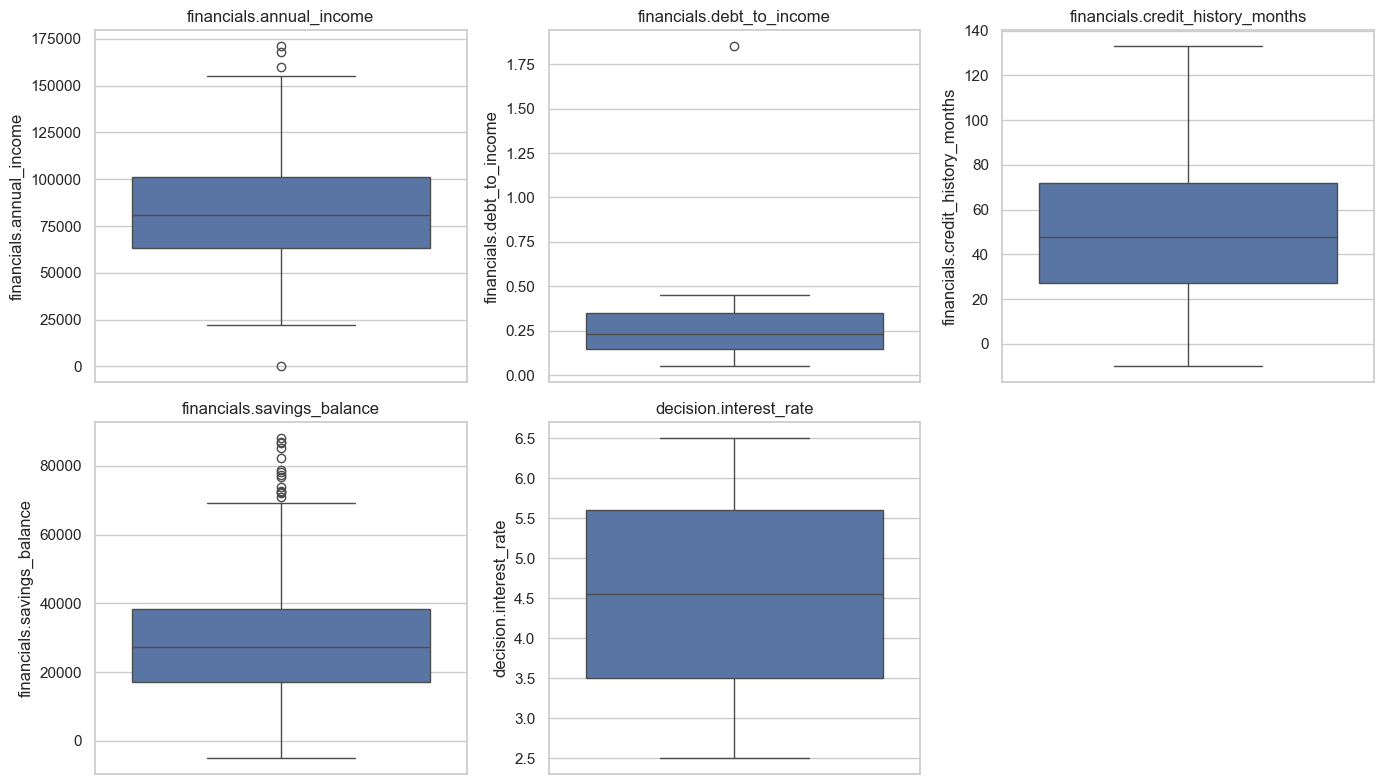

In [160]:
def iqr_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    
    mask = (series < lower) | (series > upper)
    
    return mask.sum(), lower, upper

n = len(flat)

numeric_vars = [
    "financials.annual_income",
    "financials.debt_to_income",
    "financials.credit_history_months",
    "financials.savings_balance",
    "decision.interest_rate"
]

outlier_results = {}

for col in numeric_vars:
    if col in flat.columns:
        count, lower, upper = iqr_outliers(flat[col].dropna())
        outlier_results[col] = {
            "outlier_count": count,
            "percent": round(count / n * 100, 2),
            "lower_bound": round(lower, 2),
            "upper_bound": round(upper, 2)
        }

print(pd.DataFrame(outlier_results).T)

# Set plotting style
sns.set(style="whitegrid")

# Create boxplots
plt.figure(figsize=(14, 8))

for i, col in enumerate(numeric_vars, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=flat[col])
    plt.title(col)
    plt.tight_layout()

plt.show()

## Outlier Analysis Findings

The IQR-based analysis identified statistical outliers across selected financial and decision variables.

Outliers in financial variables (e.g., income or savings balance) may reflect legitimate high-net-worth applicants rather than data errors. 

Outliers in behavioral risk variables (e.g., debt-to-income ratio or interest rate) warrant closer inspection, as extreme values may indicate underwriting anomalies or potential data recording inconsistencies.

Importantly, statistical outliers are not automatically removed, as they may carry meaningful analytical information. Their presence is documented for transparency and potential downstream modeling considerations.